# Phase 1: Data Exploration + TF-IDF Baseline

**What we'll do in this notebook:**
1. Load and explore the Jigsaw toxic comment dataset
2. Visualize label distributions and class imbalance
3. Analyze text lengths and label correlations
4. Build a TF-IDF + Logistic Regression baseline model
5. Evaluate with F1, ROC-AUC, and per-label metrics
6. Inspect what words the model learned are most predictive

**Why start here?** This is the simplest possible approach. It gives us a **baseline** — a number to beat with fancier models in later phases.

## Setup

First, we import libraries and set up the path so we can use our `src/` modules.

**`sys.path.insert(0, '..')`** — Our notebooks live in `notebooks/`, but our code is in `src/` (one folder up). This line tells Python: "when I say `from src.dataset import ...`, look one folder up to find it."

In [1]:
# This lets us import from src/ (one folder up from notebooks/)
import sys
sys.path.insert(0, '..')

# Data manipulation
import pandas as pd      # tables (DataFrames)
import numpy as np       # arrays and math

# Visualization
import matplotlib.pyplot as plt   # charts
import seaborn as sns              # prettier charts built on matplotlib

# Our own modules (from src/)
from src.dataset import load_data, get_splits, print_split_summary, clean_text, LABEL_COLS
from src.metrics import evaluate_predictions, print_metrics, save_results

# Make plots look nice
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Suppress warnings (sklearn sometimes warns about convergence)
import warnings
warnings.filterwarnings('ignore')

print('All imports successful!')
print(f'Labels we\'re predicting: {LABEL_COLS}')

Matplotlib is building the font cache; this may take a moment.


All imports successful!
Labels we're predicting: ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


---
## Part 1: Load and Explore the Data

We use our `load_data()` function from `src/dataset.py`. This loads `train.csv` into a pandas DataFrame — think of it as an Excel spreadsheet in Python.

In [2]:
# Load the dataset
df = load_data(data_dir='../data')

# .shape gives (rows, columns)
print(f'Dataset size: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

Dataset size: 159,571 rows, 8 columns
Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [3]:
# .head(5) shows the first 5 rows
# This is always the first thing you do with a new dataset — just LOOK at it
df.head(5)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


**What you're seeing:**
- `id` — unique identifier (we don't use this)
- `comment_text` — the actual Wikipedia comment
- 6 label columns — each is 0 (no) or 1 (yes)

Let's look at some specific examples:

In [4]:
# A clean comment (all labels = 0)
clean_example = df[df[LABEL_COLS].sum(axis=1) == 0].iloc[0]
# Explanation:
#   df[LABEL_COLS].sum(axis=1)  → for each row, sum all 6 labels
#   == 0                        → keep only rows where sum is 0 (no labels)
#   .iloc[0]                    → grab the first one

print('=== CLEAN COMMENT (no labels) ===')
print(f'Text: {clean_example["comment_text"][:200]}')
print(f'Labels: {dict(clean_example[LABEL_COLS])}')

=== CLEAN COMMENT (no labels) ===
Text: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove th
Labels: {'toxic': np.int64(0), 'severe_toxic': np.int64(0), 'obscene': np.int64(0), 'threat': np.int64(0), 'insult': np.int64(0), 'identity_hate': np.int64(0)}


In [5]:
# A toxic comment with multiple labels
multi_label = df[df[LABEL_COLS].sum(axis=1) >= 3].iloc[0]

print('=== MULTI-LABEL TOXIC COMMENT (3+ labels) ===')
print(f'Text: {multi_label["comment_text"][:200]}')
print(f'Labels: {dict(multi_label[LABEL_COLS])}')
print()
print('^ This comment has MULTIPLE labels at once — that\'s what "multilabel" means.')
print('  It\'s not "pick one category" — a comment can be toxic AND obscene AND insulting.')

=== MULTI-LABEL TOXIC COMMENT (3+ labels) ===
Text: COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK
Labels: {'toxic': np.int64(1), 'severe_toxic': np.int64(1), 'obscene': np.int64(1), 'threat': np.int64(0), 'insult': np.int64(1), 'identity_hate': np.int64(0)}

^ This comment has MULTIPLE labels at once — that's what "multilabel" means.
  It's not "pick one category" — a comment can be toxic AND obscene AND insulting.


---
## Part 2: Label Distribution (Class Imbalance)

**Class imbalance** = some labels are way more common than others.

This matters because a lazy model could predict "not toxic" for everything and be 90% accurate — but completely useless. That's why we use F1 score, not accuracy.

In [6]:
# Count how many comments have each label
# .sum() on a column of 0s and 1s counts the number of 1s
label_counts = df[LABEL_COLS].sum().sort_values(ascending=False)
label_pcts = (label_counts / len(df) * 100).round(2)

print('Label distribution:')
for label, count in label_counts.items():
    bar = '█' * int(label_pcts[label] * 3)  # visual bar
    print(f'  {label:15s}: {count:>6,}  ({label_pcts[label]:>5.2f}%)  {bar}')

# How many are completely clean?
n_clean = (df[LABEL_COLS].sum(axis=1) == 0).sum()
print(f'\n  Clean (no labels): {n_clean:>6,}  ({n_clean/len(df)*100:.1f}%)')
print(f'\n  Notice: "threat" is only 0.30% — that\'s ~478 out of 159K comments!')

Label distribution:
  toxic          : 15,294  ( 9.58%)  ████████████████████████████
  obscene        :  8,449  ( 5.29%)  ███████████████
  insult         :  7,877  ( 4.94%)  ██████████████
  severe_toxic   :  1,595  ( 1.00%)  ███
  identity_hate  :  1,405  ( 0.88%)  ██
  threat         :    478  ( 0.30%)  

  Clean (no labels): 143,346  (89.8%)

  Notice: "threat" is only 0.30% — that's ~478 out of 159K comments!


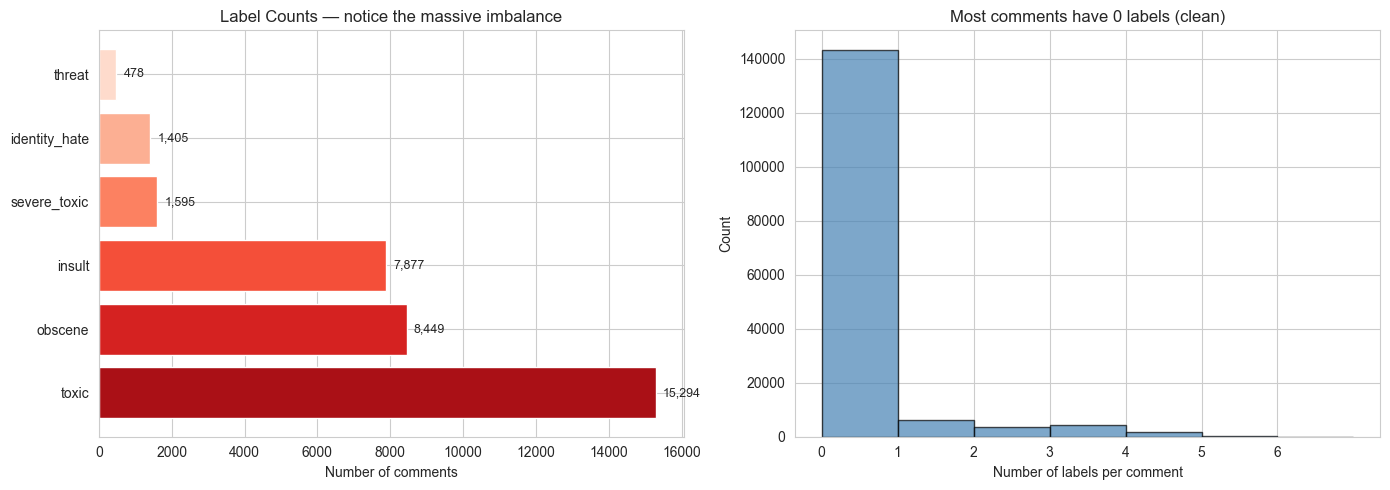

Saved to results/label_distribution.png


In [7]:
# Visualize the imbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Bar chart of label counts
colors = sns.color_palette('Reds_r', len(LABEL_COLS))
axes[0].barh(label_counts.index, label_counts.values, color=colors)
axes[0].set_xlabel('Number of comments')
axes[0].set_title('Label Counts — notice the massive imbalance')
# Add count labels on the bars
for i, (label, count) in enumerate(label_counts.items()):
    axes[0].text(count + 200, i, f'{count:,}', va='center', fontsize=9)

# RIGHT: How many labels does each comment have?
labels_per_comment = df[LABEL_COLS].sum(axis=1)
axes[1].hist(labels_per_comment, bins=range(8), edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Number of labels per comment')
axes[1].set_ylabel('Count')
axes[1].set_title('Most comments have 0 labels (clean)')
axes[1].set_xticks(range(7))

plt.tight_layout()
plt.savefig('../results/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved to results/label_distribution.png')

---
## Part 3: Label Correlation

Do some labels tend to appear together? For example, if a comment is `obscene`, is it usually also `toxic`?

A **correlation heatmap** shows this. Values close to 1.0 mean "these labels almost always appear together." Values close to 0 mean "no relationship."

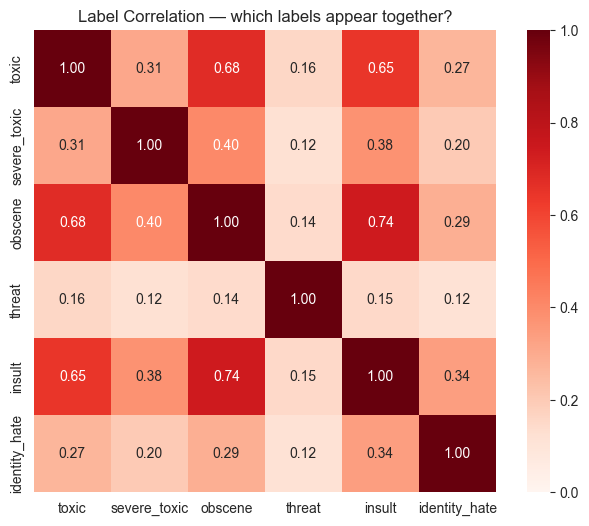

Key observations:
  - toxic & obscene: highly correlated (makes sense)
  - toxic & insult: highly correlated
  - threat has low correlation with everything (it's a different kind of toxicity)


In [8]:
# .corr() computes the Pearson correlation between all pairs of columns
corr = df[LABEL_COLS].corr()

plt.figure(figsize=(8, 6))
# annot=True puts the numbers inside each cell
# fmt='.2f' formats to 2 decimal places
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Reds', square=True,
            vmin=0, vmax=1)
plt.title('Label Correlation — which labels appear together?')
plt.savefig('../results/label_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key observations:')
print('  - toxic & obscene: highly correlated (makes sense)')
print('  - toxic & insult: highly correlated')
print('  - threat has low correlation with everything (it\'s a different kind of toxicity)')

---
## Part 4: Text Length Analysis

How long are the comments? This helps us later when we need to decide how many words to feed into the LSTM and BERT models.

In [9]:
# .str.split().str.len() splits text into words and counts them
# Example: "hello world foo".split() → ['hello', 'world', 'foo'] → len = 3
df['word_count'] = df['comment_text'].str.split().str.len()

# Tag each comment as toxic (any label = 1) or clean (all labels = 0)
# .max(axis=1) takes the max across columns for each row
# If ANY label is 1, max = 1. If all are 0, max = 0.
df['is_toxic'] = df[LABEL_COLS].max(axis=1)

# .describe() gives statistics: count, mean, std, min, 25%, 50%, 75%, max
print('Word count statistics:')
print(df.groupby('is_toxic')['word_count'].describe().round(1))
print()
print('is_toxic=0 means clean, is_toxic=1 means has at least one toxic label')

Word count statistics:
             count  mean    std  min   25%   50%   75%     max
is_toxic                                                      
0         143346.0  68.9   98.2  1.0  18.0  38.0  78.0  1250.0
1          16225.0  52.7  106.9  2.0  11.0  23.0  50.0  1411.0

is_toxic=0 means clean, is_toxic=1 means has at least one toxic label


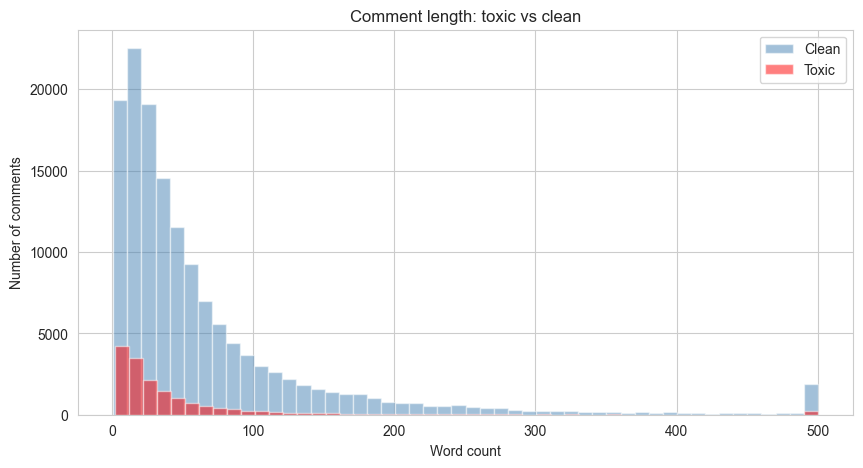

In [10]:
# Visualize: are toxic comments longer or shorter?
fig, ax = plt.subplots(figsize=(10, 5))

# .clip(upper=500) caps values at 500 for cleaner visualization
# (some comments are 5000+ words and would stretch the x-axis)
df[df['is_toxic'] == 0]['word_count'].clip(upper=500).hist(
    ax=ax, bins=50, alpha=0.5, label='Clean', color='steelblue'
)
df[df['is_toxic'] == 1]['word_count'].clip(upper=500).hist(
    ax=ax, bins=50, alpha=0.5, label='Toxic', color='red'
)
ax.set_xlabel('Word count')
ax.set_ylabel('Number of comments')
ax.set_title('Comment length: toxic vs clean')
ax.legend()

plt.savefig('../results/comment_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 5: Train/Val/Test Split

We split our data into 3 parts using our `get_splits()` function from `src/dataset.py`:
- **Train (80%)** — the model learns from this
- **Val (10%)** — we check performance while developing
- **Test (10%)** — final honest evaluation (touched ONCE at the very end)

The split is **stratified** — meaning each split has the same proportion of each label. We verified this works when we built `dataset.py`.

In [11]:
# Split the data
train_df, val_df, test_df = get_splits(df)

# Verify
print_split_summary(train_df, val_df, test_df)

Split       Size % of total
----------------------------
Train    127,656      80.0%
Val       15,957      10.0%
Test      15,958      10.0%

Label distribution (% positive) per split:
Label             Train     Val    Test
----------------------------------------
toxic             9.58%   9.58%   9.59%
severe_toxic      1.00%   1.00%   1.00%
obscene           5.29%   5.29%   5.30%
threat            0.30%   0.30%   0.29%
insult            4.94%   4.95%   4.93%
identity_hate     0.88%   0.88%   0.88%


In [12]:
# Prepare X (input text) and y (labels) for the model
# X is the text column, y is the 6 label columns as a numpy array

X_train = train_df['comment_text']
y_train = train_df[LABEL_COLS].values    # .values converts DataFrame → numpy array

X_val = val_df['comment_text']
y_val = val_df[LABEL_COLS].values

X_test = test_df['comment_text']
y_test = test_df[LABEL_COLS].values

print(f'X_train shape: {X_train.shape}  (a pandas Series of {len(X_train):,} text strings)')
print(f'y_train shape: {y_train.shape}  (a numpy array: {y_train.shape[0]:,} samples × {y_train.shape[1]} labels)')
print(f'\nExample y_train[0]: {y_train[0]}  ← labels for the first comment')

X_train shape: (127656,)  (a pandas Series of 127,656 text strings)
y_train shape: (127656, 6)  (a numpy array: 127,656 samples × 6 labels)

Example y_train[0]: [0 0 0 0 0 0]  ← labels for the first comment


---
## Part 6: TF-IDF Vectorization

Machine learning models can't read text — they need numbers. TF-IDF converts each comment into a vector of numbers.

**How TF-IDF works:**
- For each word in a comment, compute: `TF × IDF`
- **TF (Term Frequency)**: how often this word appears in THIS comment
- **IDF (Inverse Document Frequency)**: how rare this word is across ALL comments
- Common words like "the" get LOW scores (appear everywhere → low IDF)
- Meaningful words like "idiot" get HIGH scores (appear mostly in toxic comments)

**Important: fit on train, transform on val/test**
- `fit_transform(X_train)` — learn the vocabulary AND convert to numbers
- `transform(X_val)` — use the SAME vocabulary to convert (don't learn new words)
- This prevents **data leakage** — the model never sees val/test words during training

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,     # only keep top 50K words (ignore super-rare ones)
    ngram_range=(1, 2),     # use single words AND word pairs
                            #   "you suck" as a pair captures meaning that
                            #   "you" and "suck" separately don't
    sublinear_tf=True,      # use log(TF) instead of raw count
                            #   (dampens words that appear 100 times vs 10 times)
    strip_accents='unicode', # normalize accented characters (café → cafe)
    min_df=3,               # ignore words appearing in fewer than 3 comments
                            #   (too rare to be useful — probably typos)
    max_df=0.9,             # ignore words appearing in 90%+ of comments
                            #   (too common to be useful — like "the", "is")
)

# fit_transform: learn vocabulary from training data AND convert to numbers
X_train_tfidf = tfidf.fit_transform(X_train)

# transform: convert val/test using the SAME vocabulary (no new learning)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f'TF-IDF matrix shape: {X_train_tfidf.shape}')
print(f'  → {X_train_tfidf.shape[0]:,} comments, each represented as a vector of {X_train_tfidf.shape[1]:,} numbers')
print(f'  → Each number is the TF-IDF score for one word/bigram')
print(f'\nVocabulary size: {len(tfidf.vocabulary_):,} unique words/bigrams')

TF-IDF matrix shape: (127656, 50000)
  → 127,656 comments, each represented as a vector of 50,000 numbers
  → Each number is the TF-IDF score for one word/bigram

Vocabulary size: 50,000 unique words/bigrams


In [14]:
# Let's see what TF-IDF actually looks like for one comment
example_text = X_train.iloc[0]
print(f'Original text: "{example_text[:100]}..."')
print()

# Get the TF-IDF vector for this comment
example_vector = X_train_tfidf[0]

# .nonzero() finds the indices where the value is not zero
# (most values are 0 because most words don't appear in any given comment)
nonzero_indices = example_vector.nonzero()[1]
print(f'This comment has {len(nonzero_indices)} non-zero features out of {X_train_tfidf.shape[1]:,}')
print(f'(Most features are 0 because most words don\'t appear in this specific comment)')

# Show the top 10 highest TF-IDF words in this comment
feature_names = tfidf.get_feature_names_out()
scores = example_vector.toarray().flatten()
top_indices = scores.argsort()[-10:][::-1]
print(f'\nTop 10 words by TF-IDF score in this comment:')
for idx in top_indices:
    print(f'  {feature_names[idx]:20s} → {scores[idx]:.4f}')

Original text: ""

How to
I have cleaned up the page and removed whole sections on ""How-To"". How-Tos are specifica..."

This comment has 95 non-zero features out of 50,000
(Most features are 0 because most words don't appear in this specific comment)

Top 10 words by TF-IDF score in this comment:
  how to               → 0.1924
  sections             → 0.1648
  them more            → 0.1549
  seen and             → 0.1543
  indiscriminate       → 0.1528
  my self              → 0.1488
  how                  → 0.1459
  instruction          → 0.1459
  other sections       → 0.1456
  and edited           → 0.1443


---
## Part 7: Train Logistic Regression

**Logistic Regression** is the simplest classifier. For each word, it learns a weight:
- Positive weight → word suggests "yes" for this label
- Negative weight → word suggests "no" for this label
- It multiplies each word's TF-IDF score by its weight, sums them up, and outputs a probability between 0 and 1

**OneVsRestClassifier** wraps this for multilabel: it trains 6 SEPARATE logistic regressions — one per label. Each one independently answers "is this label present?"

**`class_weight='balanced'`** is how we handle class imbalance here. It tells the model: "when you see a rare `threat` example, pay MORE attention to it." Mathematically, it upweights rare classes proportionally to how rare they are.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

model = OneVsRestClassifier(
    LogisticRegression(
        C=1.0,                    # regularization strength (prevents overfitting)
        class_weight='balanced',  # upweight rare labels automatically
        solver='lbfgs',           # optimization algorithm
        max_iter=1000,            # max training iterations
    ),
    n_jobs=-1  # use all CPU cores (trains 6 classifiers in parallel)
)

print('Training 6 logistic regression classifiers (one per label)...')
model.fit(X_train_tfidf, y_train)
print('Done!')

Training 6 logistic regression classifiers (one per label)...


Done!


---
## Part 8: Evaluate on Validation Set

Now we see how good (or bad) our baseline is. We use our `src/metrics.py` module.

**Two types of predictions:**
- `.predict()` → binary 0/1 ("is it toxic? yes or no")
- `.predict_proba()` → probability between 0 and 1 ("83% chance it's toxic")

F1 score uses the binary predictions. ROC-AUC uses the probabilities.

In [16]:
# Get predictions on validation set
y_val_pred = model.predict(X_val_tfidf)         # binary: 0 or 1
y_val_proba = model.predict_proba(X_val_tfidf)  # probabilities: 0.0 to 1.0

# See what these look like
print('Example predictions for first 3 comments:')
print(f'  Binary (0/1): {y_val_pred[:3]}')
print(f'  Probabilities: {np.round(y_val_proba[:3], 3)}')
print(f'  Actual labels: {y_val[:3]}')

Example predictions for first 3 comments:
  Binary (0/1): [[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
  Probabilities: [[0.095 0.004 0.051 0.003 0.046 0.011]
 [0.008 0.024 0.029 0.01  0.026 0.007]
 [0.032 0.002 0.021 0.002 0.02  0.008]]
  Actual labels: [[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


In [17]:
# Evaluate using our metrics module
baseline_results = evaluate_predictions(y_val, y_val_pred, y_val_proba)

# Pretty-print the results
print_metrics(baseline_results, 'TF-IDF + Logistic Regression (Baseline)')


  TF-IDF + Logistic Regression (Baseline) — Evaluation Results
          Label |     F1 |   Prec |    Rec |    AUC | Support
----------------------------------------------------------------------
          toxic | 0.7363 | 0.6397 | 0.8672 | 0.9719 |    1529
   severe_toxic | 0.4119 | 0.2752 | 0.8187 | 0.9861 |     160
        obscene | 0.7762 | 0.6848 | 0.8957 | 0.9862 |     844
         threat | 0.4048 | 0.2833 | 0.7083 | 0.9889 |      48
         insult | 0.6723 | 0.5515 | 0.8608 | 0.9790 |     790
  identity_hate | 0.3783 | 0.2512 | 0.7660 | 0.9740 |     141
----------------------------------------------------------------------
      MACRO AVG | 0.5633 | 0.4476 | 0.8195 | 0.9810 |



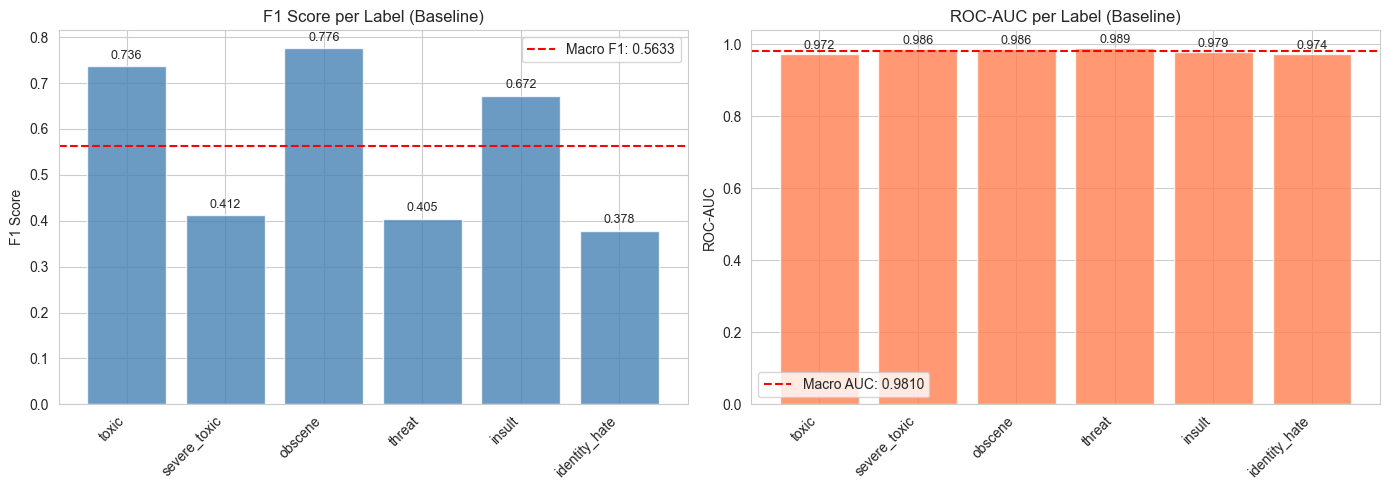

In [18]:
# Visualize per-label performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = list(baseline_results['per_label'].keys())
f1_scores = [baseline_results['per_label'][l]['f1'] for l in labels]
auc_scores = [baseline_results['per_label'][l]['roc_auc'] for l in labels]

x = range(len(labels))

# F1 per label
bars1 = axes[0].bar(x, f1_scores, color='steelblue', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score per Label (Baseline)')
macro_f1 = baseline_results['macro']['f1']
axes[0].axhline(y=macro_f1, color='red', linestyle='--',
                label=f'Macro F1: {macro_f1:.4f}')
axes[0].legend()
# Add value labels on bars
for bar, score in zip(bars1, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.3f}', ha='center', va='bottom', fontsize=9)

# ROC-AUC per label
bars2 = axes[1].bar(x, auc_scores, color='coral', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC per Label (Baseline)')
macro_auc = baseline_results['macro']['roc_auc']
axes[1].axhline(y=macro_auc, color='red', linestyle='--',
                label=f'Macro AUC: {macro_auc:.4f}')
axes[1].legend()
for bar, score in zip(bars2, auc_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{score:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/baseline_performance.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**
- ROC-AUC is high across the board (the model CAN separate toxic from clean)
- F1 varies a lot by label — common labels like `toxic` do well, rare labels like `threat` struggle
- This gap between ROC-AUC and F1 is typical for imbalanced data
- The macro F1 is what we'll try to improve in Phases 2 and 3

---
## Part 9: What Did the Model Learn?

One big advantage of logistic regression: it's **interpretable**. We can look at which words have the highest weights for each label. This tells us what the model considers most predictive.

In [19]:
# Get feature names (words/bigrams)
feature_names = np.array(tfidf.get_feature_names_out())

for i, label in enumerate(LABEL_COLS):
    # model.estimators_[i] is the logistic regression for label i
    clf = model.estimators_[i]

    # clf.coef_[0] contains the weight for every word
    # .argsort() returns indices that would sort the array
    # [-10:][::-1] grabs the top 10 highest weights
    top_idx = clf.coef_[0].argsort()[-10:][::-1]
    top_words = feature_names[top_idx]
    top_weights = clf.coef_[0][top_idx]

    print(f'\n{label.upper()} — top 10 most predictive words:')
    for word, weight in zip(top_words, top_weights):
        print(f'  {word:25s} (weight: {weight:.3f})')


TOXIC — top 10 most predictive words:
  fuck                      (weight: 18.861)
  fucking                   (weight: 17.347)
  stupid                    (weight: 16.906)
  shit                      (weight: 15.644)
  idiot                     (weight: 14.899)
  bullshit                  (weight: 12.588)
  ass                       (weight: 11.697)
  crap                      (weight: 11.518)
  asshole                   (weight: 10.555)
  suck                      (weight: 10.412)

SEVERE_TOXIC — top 10 most predictive words:
  fucking                   (weight: 12.378)
  fuck                      (weight: 11.918)
  dick                      (weight: 7.490)
  shit                      (weight: 7.274)
  asshole                   (weight: 7.197)
  bitch                     (weight: 7.122)
  die                       (weight: 7.114)
  fuckin                    (weight: 6.840)
  cocksucker                (weight: 6.821)
  motherfucking             (weight: 6.800)

OBSCENE — top 10 most 

**This is interpretability** — we can see exactly WHY the model makes each prediction. When an interviewer asks "how do you know your model isn't just memorizing noise?" — you can point to these weights and say "it learned meaningful word associations."

**But also notice the limitations:**
- TF-IDF doesn't understand word ORDER: "not bad" and "bad" look similar
- It can't handle CONTEXT: the same word might be toxic in one context and harmless in another
- It can't handle misspellings or creative obfuscation

These are the problems we'll solve with the BiLSTM (Phase 2) and BERT (Phase 3).

---
## Part 10: Save Results

We save the baseline results to a JSON file so we can compare with later models.

In [20]:
# Save results for later comparison
save_results(baseline_results, 'tfidf_logreg', results_dir='../results')

print(f'\n{"=" * 40}')
print(f'  PHASE 1 BASELINE SUMMARY')
print(f'{"=" * 40}')
print(f'  Model:     TF-IDF + Logistic Regression')
print(f'  Macro F1:  {baseline_results["macro"]["f1"]:.4f}')
print(f'  Macro AUC: {baseline_results["macro"]["roc_auc"]:.4f}')
print(f'{"=" * 40}')
print(f'\nThese are the numbers to BEAT in Phase 2 (BiLSTM) and Phase 3 (RoBERTa)!')

Results saved to ../results/tfidf_logreg_results.json

  PHASE 1 BASELINE SUMMARY
  Model:     TF-IDF + Logistic Regression
  Macro F1:  0.5633
  Macro AUC: 0.9810

These are the numbers to BEAT in Phase 2 (BiLSTM) and Phase 3 (RoBERTa)!


---
## Learning Journal

**Instructions:** Write 3-5 bullet points in your own words about what you learned. This forces you to process and internalize the concepts. These become your interview prep notes.

Fill in below:

**What I learned in Phase 1:**

- 
- 
- 
- 
- 

---
## Interview Prep Questions

Try to answer these out loud before reading the hints. An interviewer WILL ask some version of these.

1. **"Why did you use F1 instead of accuracy?"**
   - *Hint: Think about what happens with the 90% clean comments...*

2. **"What's the difference between multilabel and multiclass?"**
   - *Hint: Can a comment be obscene AND insulting at the same time?*

3. **"How does TF-IDF handle common words like 'the'?"**
   - *Hint: What does the IDF part do?*

4. **"Why did you stratify the train/test split?"**
   - *Hint: What would happen to the 478 'threat' samples with a random split?*

5. **"What can't this baseline model do?"**
   - *Hint: Does it understand word order? Context? Misspellings?*